# K08_04 – SVM Gesichtserkennung mit PCA (Dozent)

## Lernziele
Nach diesem Notebook können Sie:

- ein klassisches Beispiel für Gesichtserkennung mit SVM einordnen
- PCA als Vorverarbeitung für hochdimensionale Bilddaten verstehen
- eine Pipeline aus PCA und SVM anwenden
- Grid Search für `C` und `gamma` interpretieren

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 1. Gelabelte Gesichter laden

In [2]:
faces = fetch_lfw_people(min_faces_per_person=60, resize=0.4)

print("Klassen:", faces.target_names)
print("Bildmatrix:", faces.images.shape)
print("Feature-Matrix:", faces.data.shape)

Klassen: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
Bildmatrix: (1348, 50, 37)
Feature-Matrix: (1348, 1850)


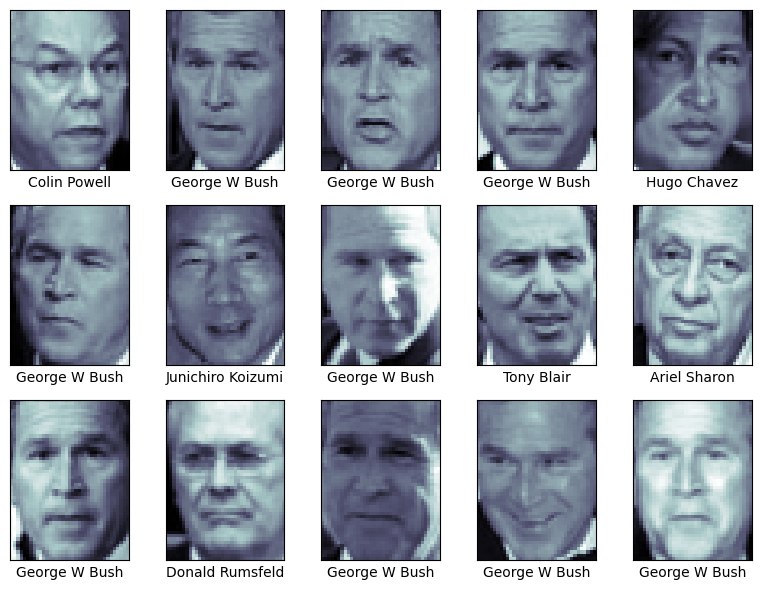

In [ ]:
fig, ax = plt.subplots(3, 5, figsize=(8, 6))
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])
plt.tight_layout()
plt.show()

## 2. Warum brauchen wir hier PCA?

Jedes Bild enthält sehr viele Pixelmerkmale.  
Eine direkte SVM auf Rohpixeln wäre oft unnötig teuer und schwerer zu interpretieren.

PCA hilft hier:
- Dimension reduzieren
- unkorrelierte Hauptkomponenten erzeugen
- die SVM auf einen kompakteren Merkmalsraum anzuwenden

In [3]:
pca = PCA(n_components=120, whiten=True, svd_solver='randomized', random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

## 3. Trainings- und Testdaten

In [4]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    faces.data, faces.target, random_state=42, stratify=faces.target
)

## 4. Grid Search für `C` und `gamma`

In [5]:
param_grid = {
    'svc__C': [1, 5, 10, 50],
    'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]
}

grid = GridSearchCV(model, param_grid)
grid.fit(Xtrain, ytrain)

print("Beste Parameter:", grid.best_params_)

Beste Parameter: {'svc__C': 5, 'svc__gamma': 0.005}


## 5. Vorhersage mit dem besten Modell

In [ ]:
best_model = grid.best_estimator_
yfit = best_model.predict(Xtest)

print(classification_report(ytest, yfit, target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       1.00      0.63      0.77        19
     Colin Powell       0.82      0.93      0.87        59
  Donald Rumsfeld       0.79      0.77      0.78        30
    George W Bush       0.88      0.94      0.91       133
Gerhard Schroeder       0.82      0.85      0.84        27
      Hugo Chavez       0.91      0.56      0.69        18
Junichiro Koizumi       1.00      0.60      0.75        15
       Tony Blair       0.82      0.89      0.85        36

         accuracy                           0.86       337
        macro avg       0.88      0.77      0.81       337
     weighted avg       0.86      0.86      0.85       337



## 6. Konfusionsmatrix

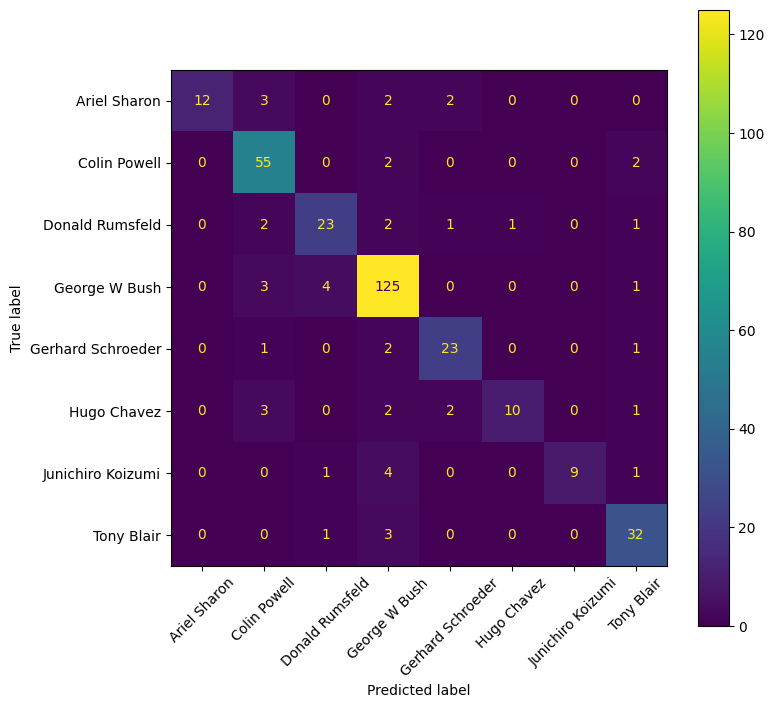

In [ ]:
cm = confusion_matrix(ytest, yfit)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=faces.target_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.show()

## 7. Längere Übungsaufgabe

1. Erklären Sie, warum PCA hier ein sinnvoller Vorverarbeitungsschritt ist.

2. Interpretieren Sie die Grid Search:
   - Warum suchen wir sowohl `C` als auch `gamma`?
   - Was bedeutet es, wenn die besten Werte am Rand des Gitters liegen?

3. Analysieren Sie die Konfusionsmatrix:
   - Welche Personen werden besonders gut erkannt?
   - Welche Verwechslungen treten auf?

4. Schreiben Sie eine kurze Reflexion:
   - Warum waren PCA + SVM lange ein starkes Standardverfahren für Gesichtserkennung?
   - Welche Grenzen hat dieses Verfahren im Vergleich zu modernen Deep-Learning-Ansätzen?

## 8. Fazit

- Gesichtserkennung mit SVM ist ein klassisches Beispiel für hochdimensionale Klassifikation.
- PCA reduziert die Bilddaten auf einen kompakteren Merkmalsraum.
- Grid Search hilft, `C` und `gamma` systematisch abzustimmen.
- Das Beispiel zeigt sehr gut die klassische Stärke von SVMs vor dem Deep-Learning-Zeitalter.

## 9. Musterlösung

### Zu 1
PCA reduziert die hohe Dimension der Bilddaten und liefert einen kompakteren Merkmalsraum.
Dadurch wird die SVM praktikabler und kann auf strukturierteren Merkmalen arbeiten.

### Zu 2
Wir suchen `C` und `gamma`, weil beide Parameter die Form der Entscheidungsgrenze stark beeinflussen:
- `C` steuert die Regularisierung
- `gamma` beeinflusst die Reichweite des RBF-Kernels

Wenn die besten Werte am Rand des Suchgitters liegen, sollte das Suchraster erweitert werden.

### Zu 3
Die Konfusionsmatrix zeigt, welche Personen häufig verwechselt werden.
Verwechslungen treten typischerweise dort auf, wo Gesichter, Beleuchtung oder Perspektiven ähnlich sind.

### Zu 4
PCA + SVM war lange ein starkes Standardverfahren, weil:
- PCA die Dimension reduziert,
- die SVM gut mit hochdimensionalen Merkmalsräumen umgehen kann,
- und das Verfahren oft gute Generalisierung liefert.

Grenzen:
- hohe Abhängigkeit von Vorverarbeitung,
- geringere Robustheit gegenüber komplexen Bildvariationen,
- heute oft von CNNs und modernen Embedding-Verfahren übertroffen.